# Business Questions

1. What is the overall overview of the dataset?

2. Which countries generate the highest revenue?

3. How do sales change year over year (YoY) and month over month (MoM)?

4. Which are the top 10 products by revenue?

5. Which 10 products have the highest negative sales?

6. Who are the top 5 customers by revenue?

7. What is the revenue contribution of known customers versus unknown customers?

8. How much sales revenue was lost due to cancelled orders?

9. Which products have the highest cancellation rates?

10. Do the top 5 customers contribute more than **X%** of the total revenue?
```

In [82]:
import pandas as  pd
var = pd.read_excel(r"D:\OneDrive\Desktop\Eda project\project_data\Online_Retail_Cleaned.xlsx")
data = pd.DataFrame(var)
pd.options.display.float_format = "{:,.2f}".format
print("Data Frame Created")


Data Frame Created


In [83]:
import matplotlib.pyplot as plt

In [84]:
data.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'sales'],
      dtype='str')

In [85]:
data.head(2)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00


---
1. What is the overall overview of the dataset?
---

In [86]:
total_sales = data[~data["Invoice"].str.startswith("C")]["sales"].sum()

No_of_customers = data["Customer ID"].nunique() 

Total_countries = data["Country"].nunique()

orders = data[~data["Invoice"].str.startswith("C")]
no_of_orders = orders["Invoice"].nunique()

orders_ = data[data["Invoice"].str.startswith("C")]
no_of_Cancels = orders_["Invoice"].nunique()

Total_quantity_sold = data[~data["Invoice"].str.startswith("C")]["Quantity"].sum()

No_of_Products = data["Description"].nunique()

low_sales = data.groupby("Description")["sales"].sum()
product_with_negative_sales = (low_sales<0).sum()

completed = data[~data["Invoice"].str.startswith("C")]

total_revenue = completed["sales"].sum()
total_orders = completed["Invoice"].nunique()

aov = total_revenue / total_orders


print("                ","---- Analysis Results ----","                  ")
print("--"*30)
print(f"Total_sales         : {round(total_sales,2):,}")
print(f"No_of_customers     : {No_of_customers:,}")
print(f"Total_countries     : {Total_countries:,}")
print(f"completed_orders    : {no_of_orders:,}")
print(f"No_of_Cancels       : {no_of_Cancels:,}")
print(f"Total_quantity_sold : {Total_quantity_sold:,}")
print(f"No_of_Products      : {No_of_Products:,}")
print(f"product_with_negative_sales : {product_with_negative_sales:,}")
print(f"Average Order value :{round(aov,2):,}")
print("--"*30)

                 ---- Analysis Results ----                   
------------------------------------------------------------
Total_sales         : 20,476,260.45
No_of_customers     : 5,940
Total_countries     : 43
completed_orders    : 40,077
No_of_Cancels       : 8,292
Total_quantity_sold : 11,205,148
No_of_Products      : 5,415
product_with_negative_sales : 33
Average Order value :510.92
------------------------------------------------------------


## Business Overview

The following key metrics provide a overview of the business performance:

- **Total Sales:** Overall revenue generated from transactions.
- **Number of Customers:** Total Customers.
- **Total Countries:** Number of countries where customers are located.
- **completed Orders:** Total orders processed.
- **Number of Cancellations:** Total cancelled transactions.
- **Total Quantity Sold:** Total units sold across all products.
- **Number of Products:** Total unique products available in the dataset.
- **Average Order Value (AOV):** Average revenue generated per order.

In [87]:
# Remove cancelled invoices to analyze completed sales only
data_without_cancels = data[~data["Invoice"].str.startswith("C")]

---
2. Which countries generate the highest revenue? 
---

In [88]:
country_generates_high_revenue = data_without_cancels.groupby("Country").agg({
    "sales":"sum",
    "Invoice":"nunique"
}).sort_values("sales",ascending=False).head(10)
country_generates_high_revenue

,sales,Invoice
Country,,
United Kingdom,"17,410,196.12",36535
EIRE,"658,767.31",626
Netherlands,"554,038.09",228
Germany,"425,019.71",789
France,"350,456.09",622
Australia,"169,283.46",95
Spain,"108,332.49",154
Switzerland,"100,685.59",93
Sweden,"91,869.82",105


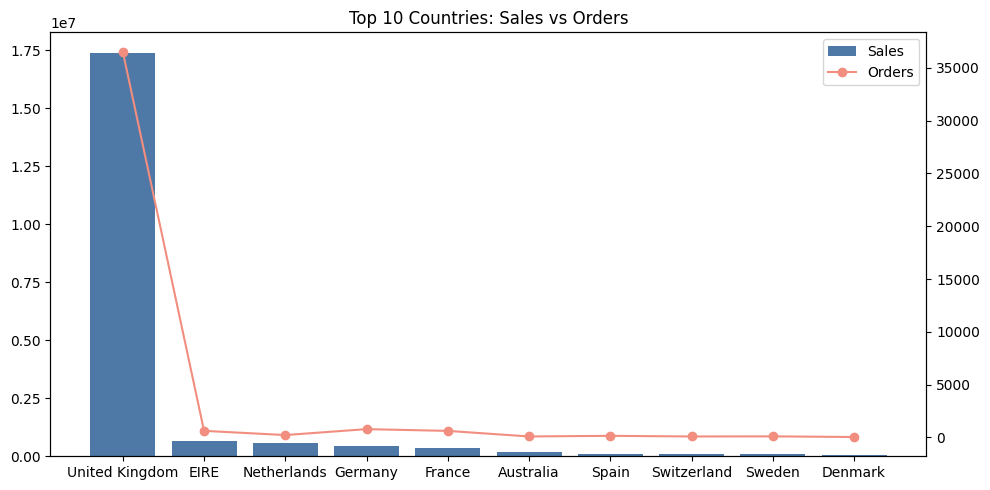

In [89]:
fig, ax1 = plt.subplots(figsize=(10,5))

bar = ax1.bar(country_generates_high_revenue.index,
              country_generates_high_revenue["sales"],
              color="#4E79A7",
              label="Sales")

ax2 = ax1.twinx()

line = ax2.plot(country_generates_high_revenue.index,
                country_generates_high_revenue["Invoice"],
                color="#F28E7F",
                marker="o",
                label="Orders")

ax1.legend([bar, line[0]], ["Sales", "Orders"])

plt.xticks(rotation=45)
plt.title("Top 10 Countries: Sales vs Orders")
plt.tight_layout()
plt.show()

# Observation

### Top 10 Countries by Sales

- The **United Kingdom** has the highest sales, with **17,410,196** in revenue.
- **Germany** and **France** have many orders, but their sales are lower than **EIRE** and the **Netherlands**.
- The **United Kingdom** earns much more revenue than the other countries.


---
3. How do sales change year over year (YoY) and month over month (MoM)?
---

In [90]:
print(data["InvoiceDate"].min())
print(data["InvoiceDate"].max())

2009-12-01 07:45:00
2011-12-09 12:50:00


In [91]:
data["year"] = data["InvoiceDate"].dt.year.astype(str)
data["month"] = data["InvoiceDate"].dt.month_name() 
data["year"] = data["year"].astype(str) 
data["Year_Month"] = data["InvoiceDate"].dt.to_period("M").astype(str)
data_without_cancels = data[~data["Invoice"].str.startswith("C")]
yearly_sales = data_without_cancels[data_without_cancels["year"] != "2009"].groupby("year")["sales"].sum()
print("--"*25)
print(yearly_sales)
print("--"*25)

--------------------------------------------------
year
2010   9,833,100.42
2011   9,820,676.07
Name: sales, dtype: float64
--------------------------------------------------


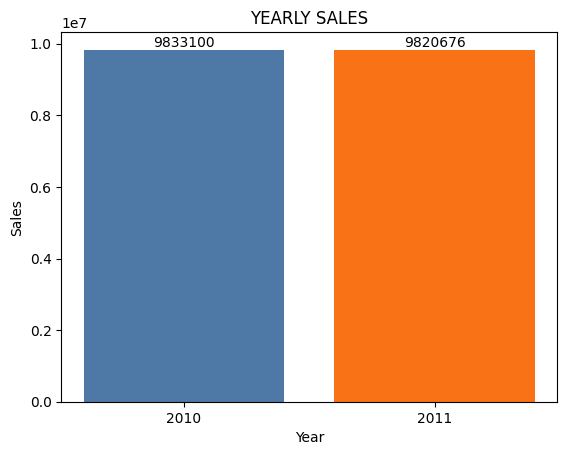

In [92]:
bar = plt.bar(yearly_sales.index, yearly_sales.values , color = ["#4E79A7", "#F97316"])
plt.title("YEARLY SALES")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.bar_label(bar, fmt="%.0f")
plt.show()

# Observation
- 2010 has good sales as compared to the 2011 
- The sales was droped by **2.3%** (2011 december data  excluded )
- **NOTE:** 2009 data excluded it has only one month data 

In [93]:
monthly_sales = data_without_cancels.groupby("Year_Month")["sales"].sum()
print("--"*25)
print(monthly_sales)
print("--"*25)

--------------------------------------------------
Year_Month
2009-12     822,483.95
2010-01     651,155.11
2010-02     551,504.73
2010-03     830,915.26
2010-04     678,875.25
2010-05     657,705.50
2010-06     749,537.31
2010-07     648,810.27
2010-08     695,251.91
2010-09     921,696.99
2010-10   1,161,902.22
2010-11   1,464,293.14
2010-12     821,452.73
2011-01     689,811.61
2011-02     522,545.56
2011-03     716,215.26
2011-04     536,968.49
2011-05     769,296.61
2011-06     760,547.01
2011-07     718,076.12
2011-08     757,841.38
2011-09   1,056,435.19
2011-10   1,151,263.73
2011-11   1,503,866.78
2011-12     637,808.33
Name: sales, dtype: float64
--------------------------------------------------


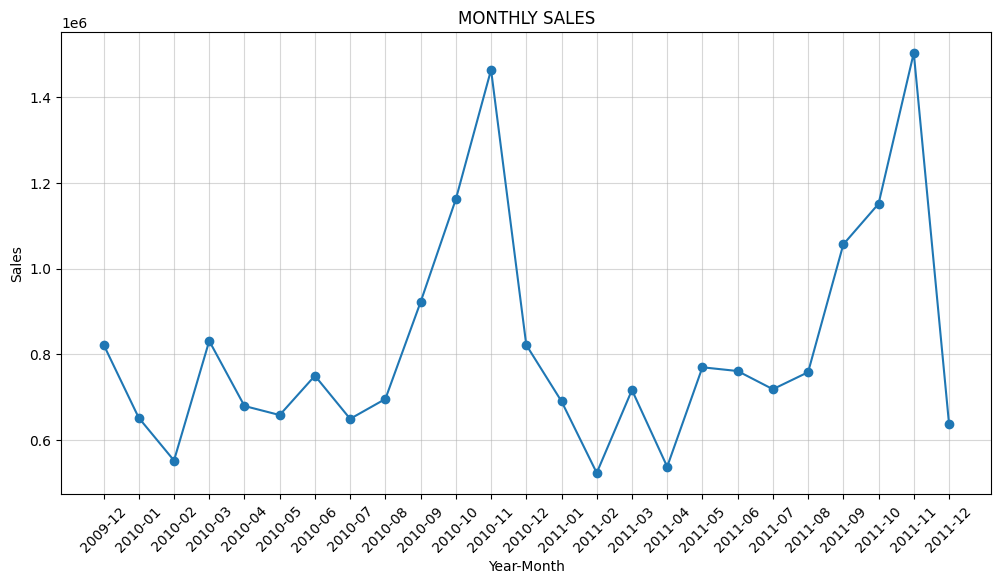

In [94]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, 
         monthly_sales.values,
         marker = "o")
plt.title("MONTHLY SALES")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.grid(alpha=0.5)
plt.ylabel("Sales")
plt.show()

# Observation

- Sales start to increase from **August** and continue to grow until **November**.
- **October** and **November** are the best-performing months in both years.
- Sales are lowest during **January** and **February**.
- Sales drop sharply in **December**, showing a seasonal sales pattern.

---
4. Which are the top 10 products by revenue?
---

In [95]:
print("--"*25)
print(" 10 Products with high sales")
print("--"*25)
Top_products = data_without_cancels[data_without_cancels["Description"] != "Manual"].groupby("Description")["sales"].sum().sort_values(
    ascending=False).head(10)
print(Top_products)
print("--"*25)

--------------------------------------------------
 10 Products with high sales
--------------------------------------------------
Description
REGENCY CAKESTAND 3 TIER             330,590.32
DOTCOM POSTAGE                       309,854.11
WHITE HANGING HEART T-LIGHT HOLDER   260,990.22
PAPER CRAFT , LITTLE BIRDIE          168,469.60
PARTY BUNTING                        148,318.28
JUMBO BAG RED RETROSPOT              148,073.47
ASSORTED COLOUR BIRD ORNAMENT        129,324.49
POSTAGE                              125,682.42
PAPER CHAIN KIT 50'S CHRISTMAS       117,760.29
MEDIUM CERAMIC TOP STORAGE JAR        81,700.92
Name: sales, dtype: float64
--------------------------------------------------


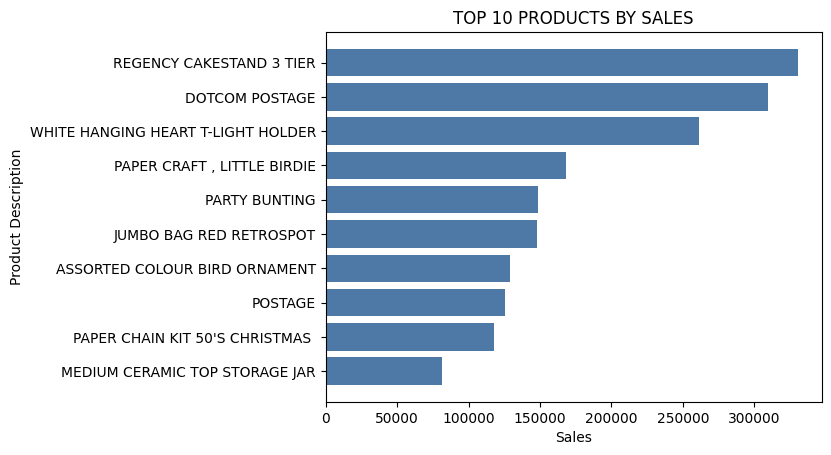

In [96]:
plt.barh(Top_products.index, 
         Top_products.values, 
         color="#4E79A7")
plt.gca().invert_yaxis()
plt.title("TOP 10 PRODUCTS BY SALES")
plt.xlabel("Sales")
plt.ylabel("Product Description")
plt.show()

# observation 
- Top 10 products with Highest Sales

---
5. Which 10 products have the highest negative sales?
---

In [97]:
exclude = [
    "AMAZON FEE",
    "Manual",
    "Bank Charges",
    "Discount",
    "CRUK Commission",
    "SAMPLES",
    " Bank Charges",
    "Adjustment by Peter on 24/05/2010 1"
]

low_sales = (
    data.groupby("Description")["sales"]
    .sum()
    .drop(exclude, errors="ignore")
    .sort_values()
    .head(10)
)

In [98]:
print("--"*25)
print(" 10 Products with low sales")
print("--"*25)
print(low_sales)
print("--"*25)

--------------------------------------------------
 10 Products with low sales
--------------------------------------------------
Description
SILVER CHERRY LIGHTS                  -591.03
WHITE CHERRY LIGHTS                   -481.24
TREE OF NOAH FESTIVE SCENTED CANDLE   -133.80
VINTAGE BLUE VACUUM FLASK 0.5L         -67.50
CREAM SWEETHEART DOUBLE SHELF          -50.85
WHITE ORCHID FLOWER LIGHTS             -45.30
PADS TO MATCH ALL CUSHIONS             -36.58
VINTAGE WOOD ORGANISER                 -33.90
S/16 BLACK SHINY/MAT BAUBLES           -29.40
SET 6 MINI SUSHI SET FRIDGE MAGNETS    -20.28
Name: sales, dtype: float64
--------------------------------------------------


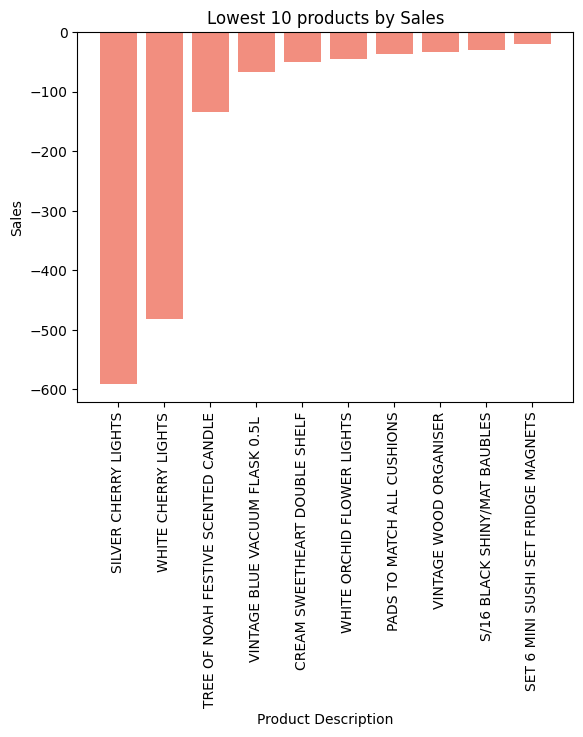

In [99]:
plt.bar(low_sales.index,
        low_sales.values, 
        color="#F28E7F")
plt.xlabel("Product Description")
plt.ylabel("Sales")
plt.title("Lowest 10 products by Sales")
plt.xticks(rotation=90)
plt.show()

# observation 
- 10 products with Negative Sales
- These Products have More Cancellation 

---
6. Who are the top 5 customers by revenue?
---

In [100]:
data["Customer ID"] = data["Customer ID"].astype(str)
print("--"*25)
print(" Top 5 Customers")
print("--"*25)
data_without_cancels = data[~data["Invoice"].str.startswith("C")]
Top_5 = data_without_cancels[data_without_cancels["Customer ID"] != "Unknown"].groupby("Customer ID")["sales"].sum().sort_values(
    ascending=False).head(5)
print(Top_5)
print("--"*25)

--------------------------------------------------
 Top 5 Customers
--------------------------------------------------
Customer ID
18102   580,987.04
14646   528,602.52
14156   313,437.62
14911   291,420.81
17450   244,784.25
Name: sales, dtype: float64
--------------------------------------------------


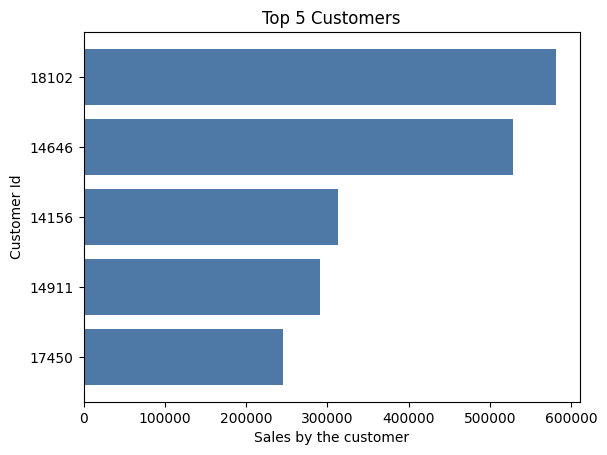

In [101]:
plt.barh(Top_5.index, 
         Top_5.values , 
         color="#4E79A7")
plt.title("Top 5 Customers")
plt.xlabel("Sales by the customer")
plt.ylabel("Customer Id")
plt.gca().invert_yaxis()
plt.show()

# Observation

- Customer **18102** is the top customer, generating **580,987** in total sales.
- Customer **14646** is the second-highest customer, with **528,602** in total sales.
- The top two customers generate much higher sales than the other top five customers.

---
7. What is the revenue contribution of known customers versus unknown customers?
---

In [102]:
def customer(Customer_ID):
    if Customer_ID == "Unknown":
        return "Unknown"
    else :
        return "known"

data["Customer_type"]  = data["Customer ID"].apply(customer)
data_without_cancels = data[~data["Invoice"].str.startswith("C")]

In [103]:
contribution = (data_without_cancels.groupby("Customer_type")["sales"].sum()/data_without_cancels["sales"].sum())*100
print(contribution)

Customer_type
Unknown   15.15
known     84.85
Name: sales, dtype: float64


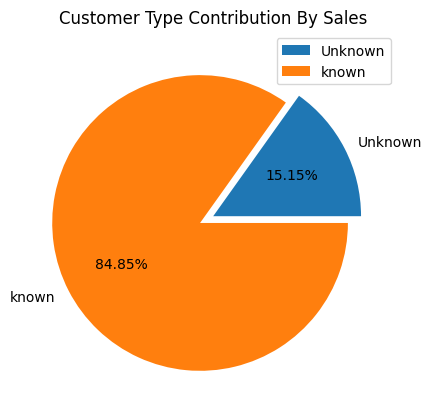

In [104]:
plt.pie(contribution,
        labels= contribution.index ,
        autopct="%1.2f%%" ,
        explode=[0,0.1])
plt.title("Customer Type Contribution By Sales")
plt.legend()
plt.show()

# Observation

- **Known customers** generate more sales than **Unknown customers**.
- **Known customers** contribute **84.85%** of the total sales.
- **Unknown customers** contribute **15.15%** of the total sales.

In [105]:
# No of customers by type
types = data["Customer_type"].value_counts()

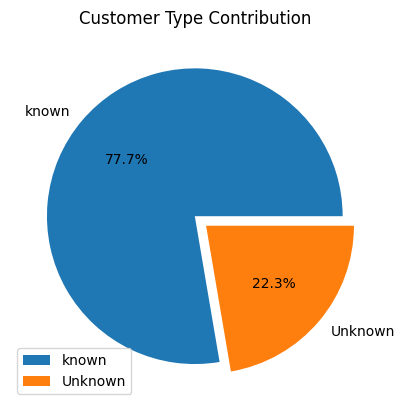

In [106]:
plt.pie(types,
        labels = types.index ,
        autopct="%1.1f%%",
        explode=[0,0.1])
plt.title("Customer Type Contribution")
plt.legend()
plt.show()

# Observation

- **Known customers** account for **77.7%** of the total customers.
- **Unknown customers** account for **22.3%** of the total customers.
- The majority of customers are **known customers**.


---
8. How much sales revenue was lost due to cancelled orders?
---

In [107]:
def canclation(var_):
    if var_.startswith("C"):
        return "Cancelled"
    else :
        return "Completed"

In [108]:
data["Status"] = data["Invoice"].apply(canclation)
status_sales = data.groupby("Status")["sales"].sum()
status_sales

Status
Cancelled   -1,462,050.61
Completed   20,476,260.45
Name: sales, dtype: float64

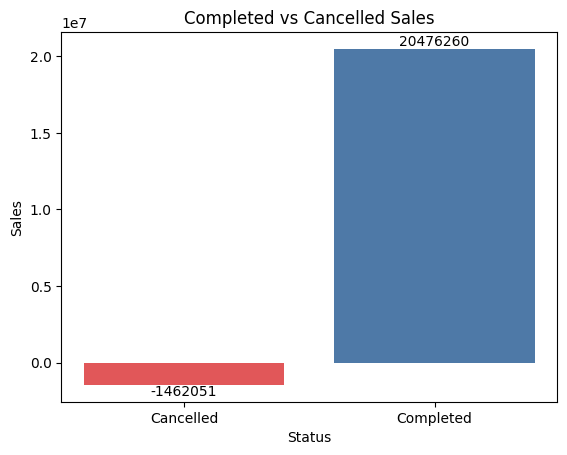

In [109]:
bars = plt.bar(status_sales.index,
               status_sales.values,
               color=["#E15759", "#4E79A7"])

plt.title("Completed vs Cancelled Sales")
plt.xlabel("Status")
plt.ylabel("Sales")
plt.bar_label(bars,fmt="%.0f")
plt.show()

# Observation

- Cancelled orders account for **1,462,051** in potential sales.
- Completed orders generated **20,476,260** in total sales.
- If the cancelled orders had been completed, the total sales would have been **21,938,311**.
- Cancelled orders are equal to **7.14%** of the completed sales.

---
9. Which products have the highest cancellation rates?
---

In [110]:
cancellation_rate = data.groupby("Description")["Status"].value_counts().unstack()

cancellation_rate["Cancellation %"] = cancellation_rate["Cancelled"] * 100 / (
    cancellation_rate["Cancelled"] + cancellation_rate["Completed"]
)

cancellation_rate = cancellation_rate.sort_values("Cancellation %", ascending=False).drop(exclude,errors="ignore").head(10)
cancellation_rate


Status,Cancelled,Completed,Cancellation %
Description,,,
FEATHER HEART LIGHTS,4.00,1.00,80.00
RED HEART CANDY POP LIGHTS,3.00,1.00,75.00
CREAM SWEETHEART DOUBLE SHELF,2.00,1.00,66.67
CERAMIC CAKE TEAPOT WITH CHERRY,2.00,1.00,66.67
SILVER CHERRY LIGHTS,20.00,12.00,62.50
WHITE CHERRY LIGHTS,121.00,106.00,53.30
"GLASS JAR, ENGLISH CONFECTIONERY",1.00,1.00,50.00
WHITE SCANDINAVIAN HEART CHRISTMAS,1.00,1.00,50.00
WOODLAND CREATURES WRAP,1.00,1.00,50.00


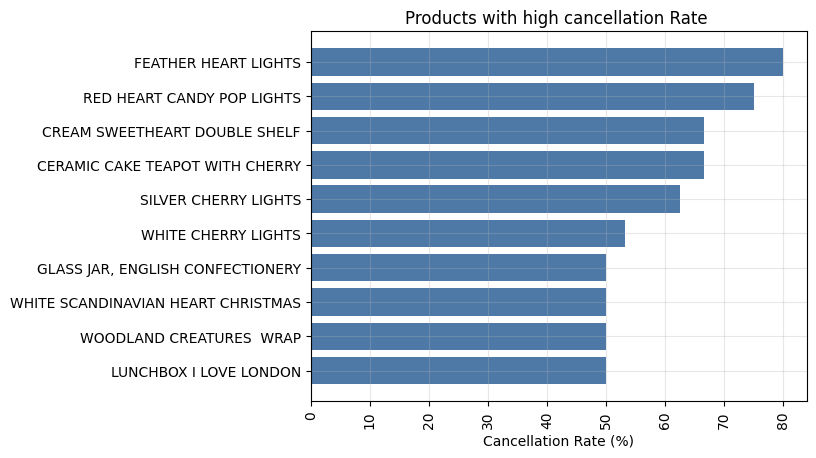

In [111]:
plt.barh(cancellation_rate.index,cancellation_rate["Cancellation %"] , color ="#4E79A7")
plt.gca().invert_yaxis()
plt.title("Products with high cancellation Rate ")
plt.xlabel("Cancellation Rate (%)")
plt.xticks(rotation = 90)
plt.grid(alpha=0.3)
plt.show()

# Observation

- **FEATHER HEART LIGHTS** has the highest cancellation rate at **80%**.
- **RED HEART CANDY POP LIGHTS** has the second-highest cancellation rate at **75%**.
- **WHITE CHERRY LIGHTS** has the highest number of cancelled orders (**121**), even though its cancellation rate is **53.30%**.

---
10. Do the top 5 customers contribute more than **X%** of the total revenue
---

In [115]:
top_10 = data_without_cancels[data_without_cancels["Customer ID"] != "Unknown"].groupby("Customer ID")["sales"] .sum().sort_values(ascending=False).head(10)
percentage = round((top_10.sum()/data[data["Customer ID"] != "Unknown"]["sales"].sum())*100, 1)
print("--"*25)
print("Top10 customers contribution to total sales")
print("--"*25)
print(percentage)
print("--"*25)

--------------------------------------------------
Top10 customers contribution to total sales
--------------------------------------------------
17.1
--------------------------------------------------


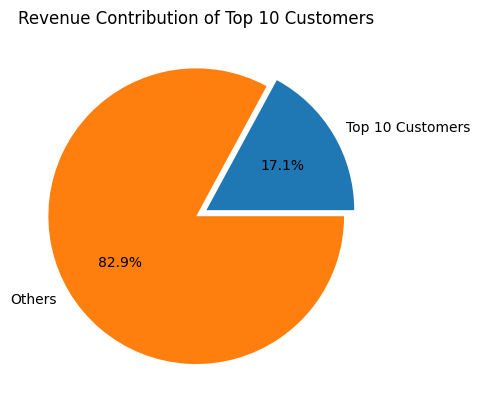

In [116]:
plt.pie(
    [percentage, 100 - percentage],
    labels=["Top 10 Customers", "Others"],
    autopct="%.1f%%",
    explode=[0.08, 0]
)

plt.title("Revenue Contribution of Top 10 Customers")
plt.show()

# Observation

- The Revenue contribution by Top 10 customers are **16.3**

In [ ]:
data.to_excel(
    r"D:\OneDrive\Desktop\Eda project\project_data\Final_Dataset.xlsx",
    index=False
)

#                                    END OF ANAYLSIS 